In [21]:
# 라이브러리 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [22]:
# 1. 데이터 로딩
columns = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

train_df = pd.read_csv(
    'data/raw/KDDTrain+.txt',
    header=None,
    names=columns
)

print("데이터 로딩 완료")
print(f"shape: {train_df.shape}")

train_df.head()

데이터 로딩 완료
shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [23]:
# 2. 결측치 & 데이터 타입 확인 -> 결측치 없음 확
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [24]:
# 3. 클래스 분포 확인
print("=== 클래스 분포 ===")
print(train_df['label'].value_counts())
print()
print("=== 비율 (%) ===")
print(round(train_df['label'].value_counts(normalize=True) * 100, 2))

=== 클래스 분포 ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

=== 비율 (%) ===
label
normal             53.46
neptune            32.72
satan               2.88
ipsweep             2.86
portsweep           2.33
smurf               2.10
nmap                1.19
back                0.76
teardrop            0.71
warezclient         0.71
pod                 0.16
guess_passwd        0.04
buffer_overflow     0.02
warezmaster         0.02
land  

In [25]:
# 4. 레이블 매핑
# 공격 유형 → 5개 카테고리 매핑
attack_map = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

train_df['attack_type'] = train_df['label'].map(attack_map)

print("=== 5개 카테고리 분포 ===")
print(train_df['attack_type'].value_counts())
print()
print("=== 비율 (%) ===")
print(round(train_df['attack_type'].value_counts(normalize=True) * 100, 2))

=== 5개 카테고리 분포 ===
attack_type
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

=== 비율 (%) ===
attack_type
Normal    53.46
DoS       36.46
Probe      9.25
R2L        0.79
U2R        0.04
Name: proportion, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26740\415472711.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


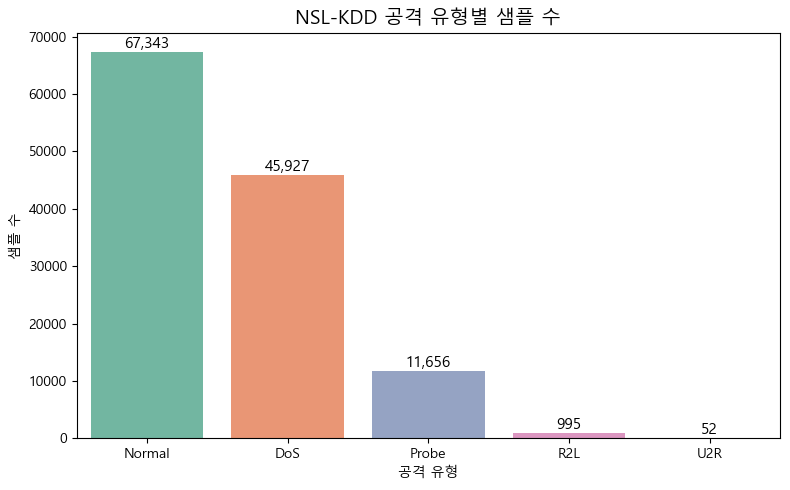

In [27]:
# 5. 클래스 분포 시각화
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x='attack_type',
    order=train_df['attack_type'].value_counts().index,
    palette='Set2'
)

# 각 막대 위에 숫자 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('NSL-KDD 공격 유형별 샘플 수', fontsize=14)
plt.xlabel('공격 유형')
plt.ylabel('샘플 수')
plt.tight_layout()
plt.show()

In [12]:
# 6. 피치 타입 분리 
categorical = train_df.select_dtypes(include='object').columns.tolist()              # 범주형
numerical = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()    # 수치형

print("범주형 피처:", categorical)
print()
print("수치형 피처 수:", len(numerical))
print(numerical)

범주형 피처: ['protocol_type', 'service', 'flag', 'label', 'attack_type']

수치형 피처 수: 39
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty']


In [15]:
# 7. 수치형 피처 기초 통계
numerical_features = [col for col in numerical if col != 'difficulty'] # difficulty 컬럼 제외 (탐지 난이도 점수로서, 실제 네트워크에서는 존재하지 않는 값)

print("=== 수치형 피처 기초 통계 ===")
train_df[numerical_features].describe()

=== 수치형 피처 기초 통계 ===


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


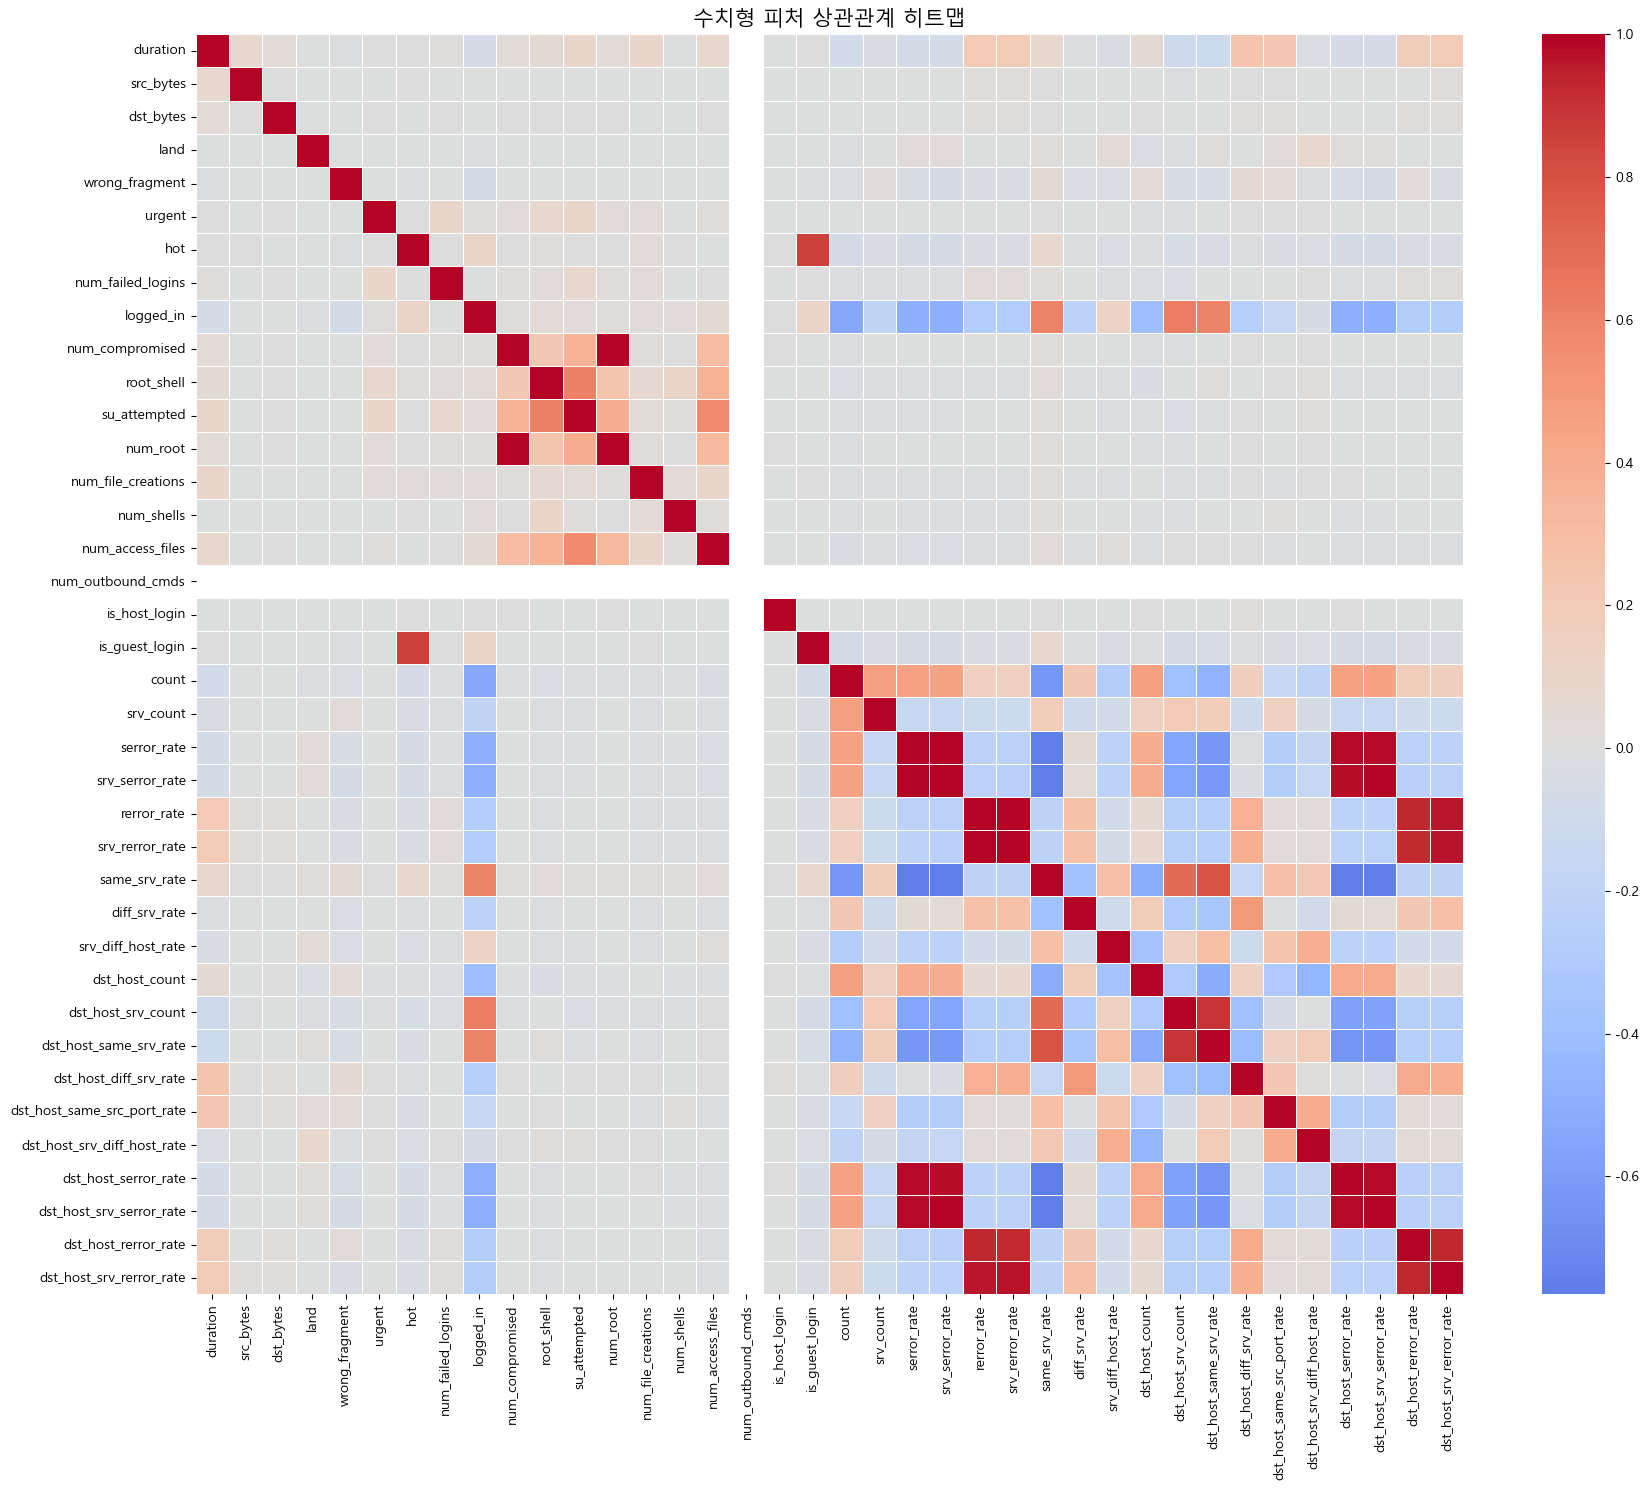

In [28]:
# 8. 상관관계 히트맵 -> 다중공선성 그룹 2개 발
plt.figure(figsize=(18, 15))
corr_matrix = train_df[numerical_features].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=False
)

plt.title('수치형 피처 상관관계 히트맵', fontsize=15)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26740\1643369768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26740\1643369768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26740\1643369768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26740\1643369768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

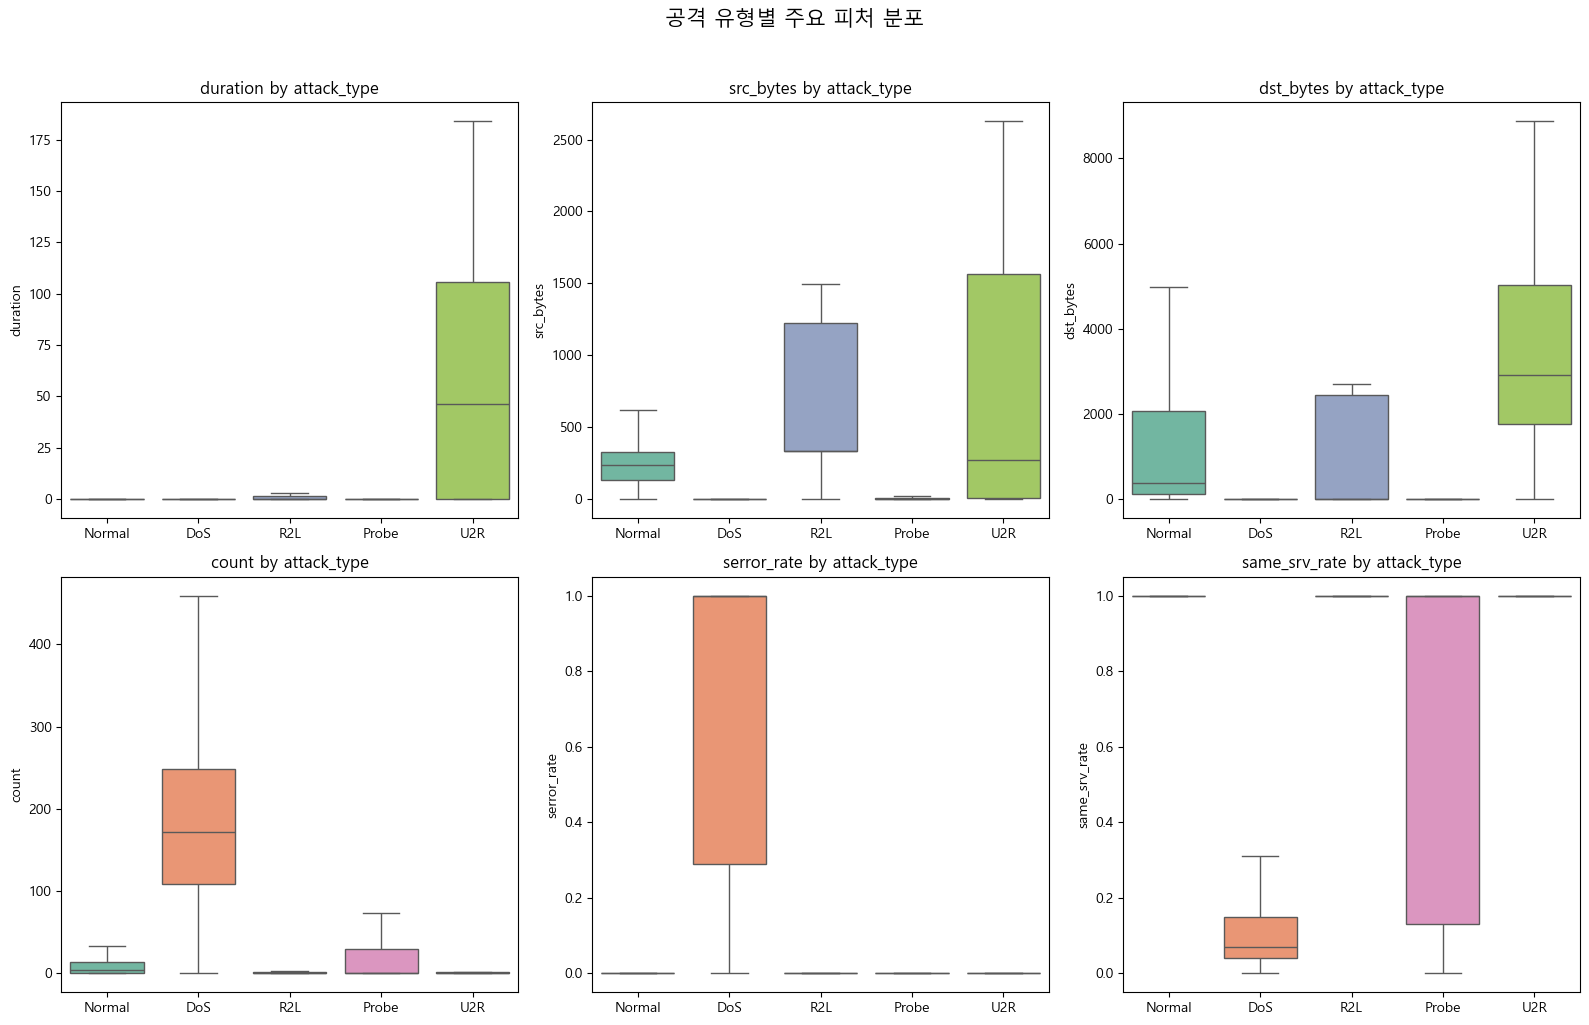

In [17]:
# 9. 공격 유형별 피처 분포 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = [
    'duration', 'src_bytes', 'dst_bytes',
    'count', 'serror_rate', 'same_srv_rate'
]

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.boxplot(
        data=train_df,
        x='attack_type',
        y=feature,
        palette='Set2',
        ax=ax,
        showfliers=False  # 이상값 제외하고 전체 분포 파악
    )
    ax.set_title(f'{feature} by attack_type')
    ax.set_xlabel('')

plt.suptitle('공격 유형별 주요 피처 분포', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()